In [2]:
#fetch financial data from various sources such as Yahoo Finance, Alpha Vantage, FRED (Federal Reserve Economic Data),
!pip install pandas_datareader 

   ---------------------------------------- 0.0/109.5 kB ? eta -:--:--
   --- ------------------------------------ 10.2/109.5 kB ? eta -:--:--
   --- ------------------------------------ 10.2/109.5 kB ? eta -:--:--
   ---------- ---------------------------- 30.7/109.5 kB 217.9 kB/s eta 0:00:01
   -------------- ------------------------ 41.0/109.5 kB 196.9 kB/s eta 0:00:01
   --------------------- ----------------- 61.4/109.5 kB 252.2 kB/s eta 0:00:01
   ------------------------- ------------- 71.7/109.5 kB 262.6 kB/s eta 0:00:01
   ----------------------------------- -- 102.4/109.5 kB 328.0 kB/s eta 0:00:01
   -------------------------------------- 109.5/109.5 kB 288.4 kB/s eta 0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
    --------------------------------------- 0.1/4.0 MB 2.0 MB/s eta 0:00:02
   - -------------------------------------- 0.1/4.0 MB 2.2 MB/s eta 0:00:02
   - -------------------------------------- 0.1/4.0 MB 1.2 MB/s eta 0:00:04
   -- --


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
!pip install yfinance


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf
import pandas_datareader # Up-to-date remote data access for pandas
import datetime  #  datetime module supplies classes for manipulating dates and times
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
display("Practice exercise two")

'Practice exercise two'

In [3]:
display("Question 1: Download and plot US auto and housing sales since 1990")

'Question 1: Download and plot US auto and housing sales since 1990'

In [4]:
# Download financial data
data = yf.download("^GSPC", '1990-01-01', interval = "1d") # Download S&P500 data
# take close only
data_sp_adj_close = pd.DataFrame(data["Close"])
data_sp_adj_close = data_sp_adj_close.rename(columns={"Close": "SP500"})
data_sp_adj_close.tail(10)

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2026-02-02,6976.439941
2026-02-03,6917.810059
2026-02-04,6882.720215
2026-02-05,6798.399902
2026-02-06,6932.299805
2026-02-09,6964.819824
2026-02-10,6941.810059
2026-02-11,6941.470215
2026-02-12,6832.759766


In [5]:
start = datetime.datetime(1990, 1, 1)
start

datetime.datetime(1990, 1, 1, 0, 0)

In [6]:
# Download Economic data from Fred
start = datetime.datetime(1990, 1, 1)
data = pandas_datareader.fred.FredReader(['TOTALSA','HSN1F'], start = start)
df = data.read()
print('TOTALSA: Total Vehicle Sales. Last observation: 2025-01-01')
print('HSN1F: New One Family Houses Sold. Last observation: 2024-12-01')
# interpolate dates
df = df.reindex(pd.date_range(start=df.index.min(), end=df.index.max(),freq='1D')) # will have dates as index (not as a separate column)
df.tail(40)

TOTALSA: Total Vehicle Sales. Last observation: 2025-01-01
HSN1F: New One Family Houses Sold. Last observation: 2024-12-01


,TOTALSA,HSN1F
2025-11-23,NaN,NaN
2025-11-24,NaN,NaN
2025-11-25,NaN,NaN
2025-11-26,NaN,NaN
2025-11-27,NaN,NaN
2025-11-28,NaN,NaN
2025-11-29,NaN,NaN
2025-11-30,NaN,NaN
2025-12-01,16.394,NaN
2025-12-02,NaN,NaN


In [ ]:
# Download Economic data from Fred
start = datetime.datetime(1990, 1, 1)
data = pandas_datareader.fred.FredReader(['TOTALSA','HSN1F'], start = start)
df = data.read()
print('TOTALSA: Total Vehicle Sales. Last observation: 2025-01-01')
print('HSN1F: New One Family Houses Sold. Last observation: 2024-12-01')
# interpolate dates
df = df.reindex(pd.date_range(start=df.index.min(), end=df.index.max(),freq='1D')) # will have dates as index (not as a separate column)
df.tail(40)

TOTALSA: Total Vehicle Sales. Last observation: 2025-01-01
HSN1F: New One Family Houses Sold. Last observation: 2024-12-01


,TOTALSA,HSN1F
2024-11-23,NaN,NaN
2024-11-24,NaN,NaN
2024-11-25,NaN,NaN
2024-11-26,NaN,NaN
2024-11-27,NaN,NaN
2024-11-28,NaN,NaN
2024-11-29,NaN,NaN
2024-11-30,NaN,NaN
2024-12-01,17.323,698.0
2024-12-02,NaN,NaN


In [7]:
data_sp_adj_close

Ticker,^GSPC
Date,
1990-01-02,359.690002
1990-01-03,358.760010
1990-01-04,355.670013
1990-01-05,352.200012
1990-01-08,353.790009
...,...
2026-02-09,6964.819824
2026-02-10,6941.810059
2026-02-11,6941.470215


In [8]:
# Merge the two dataset
df = df.merge(data_sp_adj_close, left_index=True, right_index=True)
df.head()

,TOTALSA,HSN1F,^GSPC
1990-01-02,NaN,NaN,359.690002
1990-01-03,NaN,NaN,358.760010
1990-01-04,NaN,NaN,355.670013
1990-01-05,NaN,NaN,352.200012
1990-01-08,NaN,NaN,353.790009


In [9]:
# Take only end of month, but first carry forward information
df = df.fillna(method='ffill')
df["DATE"] = df.index.values
df = df[pd.to_datetime(df["DATE"]).dt.is_month_end]   # keep month
df.tail(20)

C:\Users\Nb736\AppData\Local\Temp\ipykernel_36892\3149608148.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,TOTALSA,HSN1F,^GSPC,DATE
2023-08-31,16.071,645.0,4507.660156,2023-08-31
2023-10-31,16.209,681.0,4193.799805,2023-10-31
2023-11-30,15.782,610.0,4567.799805,2023-11-30
2024-01-31,16.321,643.0,4845.649902,2024-01-31
2024-02-29,16.255,658.0,5096.270020,2024-02-29
2024-04-30,16.459,719.0,5035.689941,2024-04-30
2024-05-31,16.361,665.0,5277.509766,2024-05-31
2024-07-31,16.337,710.0,5522.299805,2024-07-31
2024-09-30,15.977,693.0,5762.479980,2024-09-30
2024-10-31,16.493,621.0,5705.450195,2024-10-31


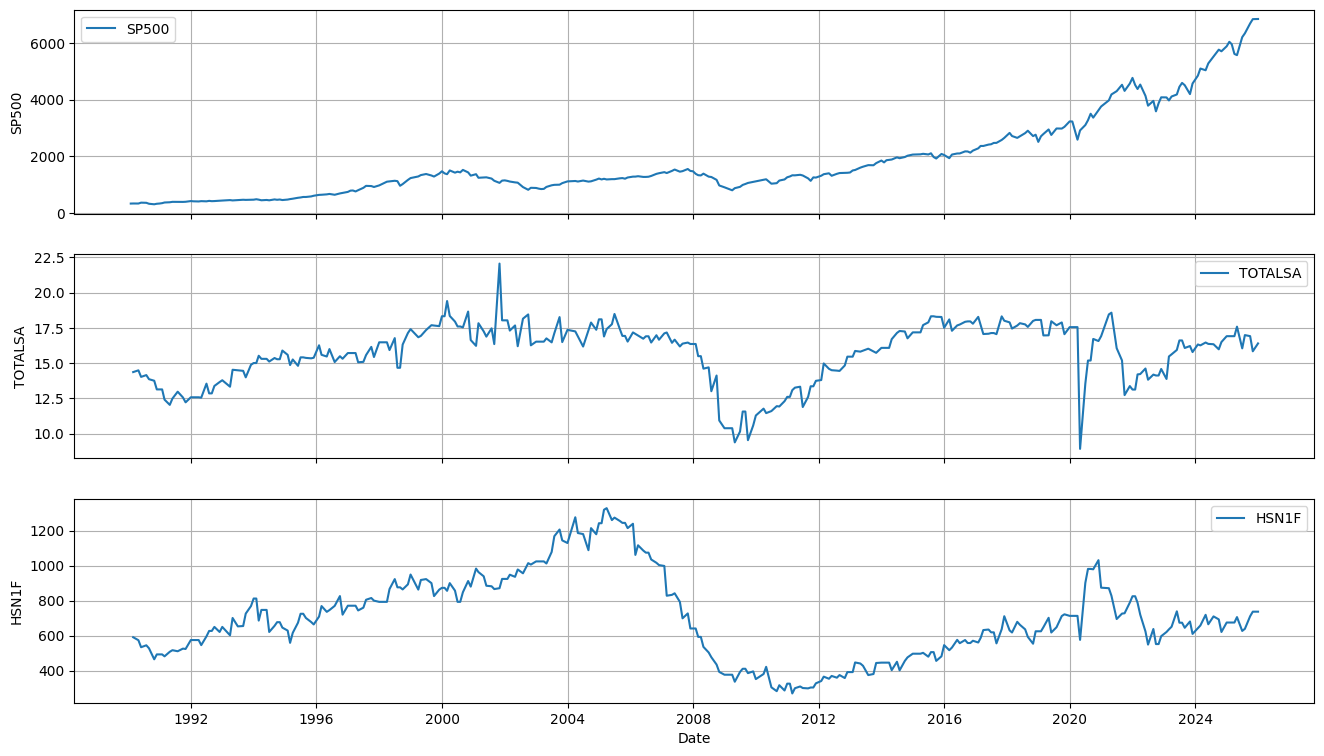

In [10]:
# Plot
fig, ax = plt.subplots(3, sharex=True, sharey=False,figsize=(16,9))
ax[0].plot(df["^GSPC"], label = "SP500")
ax[0].set_ylabel('SP500')
ax[0].legend()
ax[0].grid()
ax[1].plot(df["TOTALSA"], label = "TOTALSA")
ax[1].set_ylabel('TOTALSA')
ax[1].legend()
ax[1].grid()
ax[2].plot(df["HSN1F"], label = "HSN1F")
ax[2].set_xlabel('Date')
ax[2].set_ylabel('HSN1F')
ax[2].legend()
ax[2].grid()

In [ ]:
display("Question 2: What transformations should we perform on the data? Why?")

'Question 2: What transformations should we perform on the data? Why?'

In [11]:
# Compute Log returns
df['SP500_log_chg'] = np.log(df["^GSPC"]) - np.log(df["^GSPC"].shift(1))
df['TOTALSA_log_chg'] = np.log(df["TOTALSA"]) - np.log(df["TOTALSA"].shift(1))
df['HSN1F_log_chg'] = np.log(df["HSN1F"]) - np.log(df["HSN1F"].shift(1))

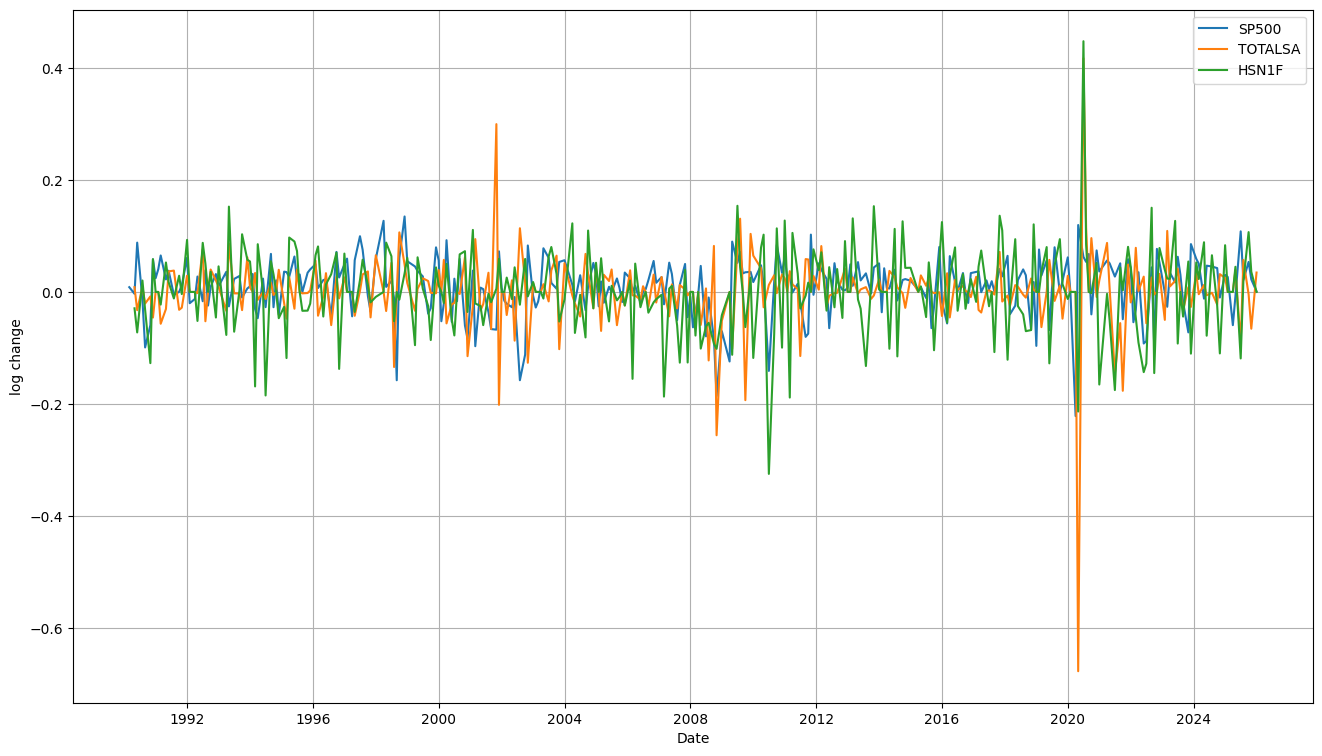

In [12]:
# Chart
# Plot
fig, ax = plt.subplots(figsize=(16,9))
ax.plot(df["SP500_log_chg"], label = "SP500")
ax.plot(df["TOTALSA_log_chg"], label = "TOTALSA")
ax.plot(df["HSN1F_log_chg"], label = "HSN1F")
ax.set_xlabel('Date')
ax.set_ylabel('log change')
ax.legend()
ax.grid()

In [ ]:
display("Question 3: What lags would we need to apply to test link with US stock market? Why?")

'Question 3: What lags would we need to apply to test link with US stock market? Why?'

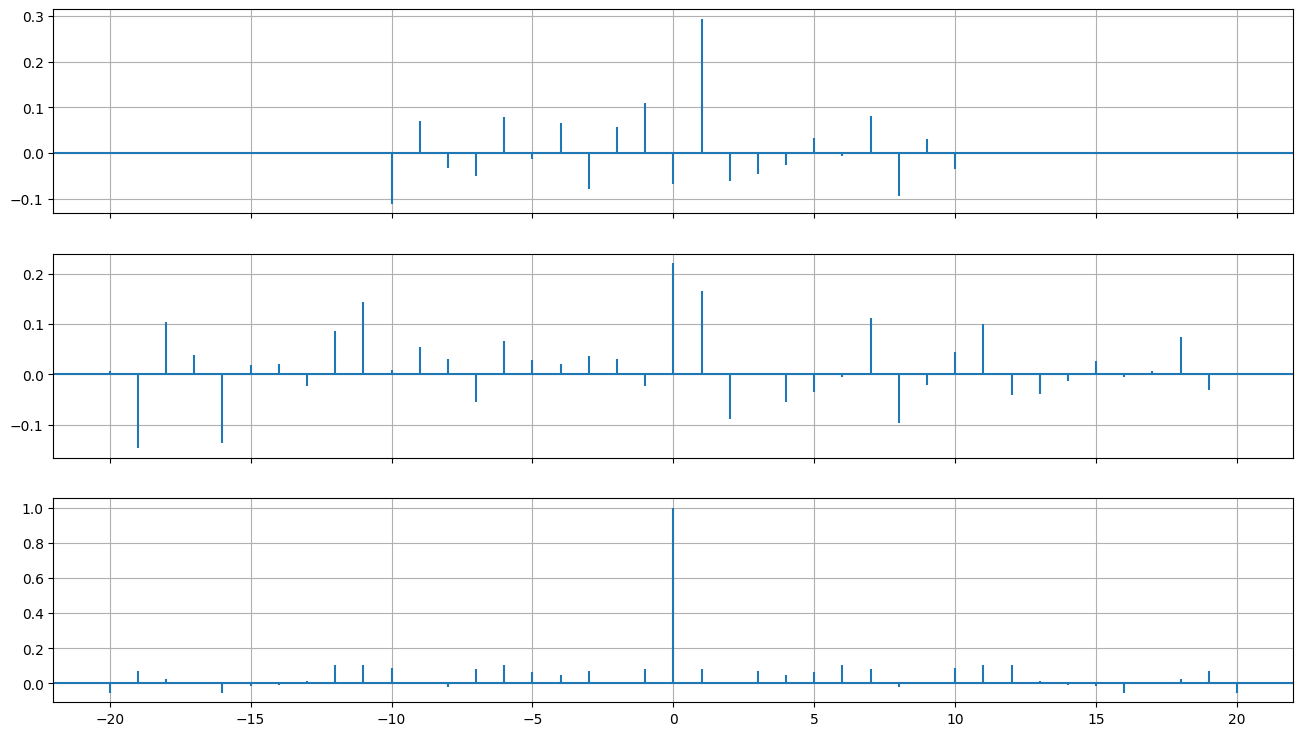

In [20]:
# Lead lag analysis without accounting for publication lag (1st input shifts on the x-axis)
fig, [ax1, ax2, ax3] = plt.subplots(3, 1, sharex=True, figsize=(16,9))
ax1.xcorr(df["TOTALSA_log_chg"][2:len(df)], df["SP500_log_chg"][2:len(df)], usevlines=True,  maxlags=10)  # cross autocorrelation Total Vehicle Sales  has some predicatibility over next months' returns
ax1.grid(True)
ax2.xcorr(df["HSN1F_log_chg"][2:len(df)], df["SP500_log_chg"][2:len(df)], usevlines=True, maxlags=20)  # cross autocorrelation house sales  has some (smaller) predicatibility over next months' returns
ax2.grid(True)
ax3.acorr(df["SP500_log_chg"][2:len(df)], usevlines=True, normed=True, maxlags=20)  #  autocorrelation pure evidence
ax3.grid(True)
plt.show()

In [21]:
# Function to compute beta OLS
def Beta_OLS(y,X):
    return np.linalg.inv(np.matrix(X).T*np.matrix(X))*np.matrix(X).T*np.matrix(y).T

In [22]:
# Compute lagged values
df["SP500_log_chg_lag"] = df["SP500_log_chg"].shift(1)  # Compute lag 1 returns of SNP
df["HSN1F_log_chg_lag"] = df["HSN1F_log_chg"].shift(1)  # Compute lag 1 returns of HOUSING
df["TOTALSA_log_chg_lag"] = df["TOTALSA_log_chg"].shift(1)    # Compute lag 1 returns of Total Vehicle Sales
df["TOTALSA_log_chg_lag_lag"] = df["TOTALSA_log_chg_lag"].shift(1)    # Compute 2 lag returns of Total Vehicle Sales
# drop first missings
df = df[4:len(df)]
df.head()

,TOTALSA,HSN1F,^GSPC,DATE,SP500_log_chg,TOTALSA_log_chg,HSN1F_log_chg,SP500_log_chg_lag,HSN1F_log_chg_lag,TOTALSA_log_chg_lag,TOTALSA_log_chg_lag_lag
1990-12-31,13.134,493.0,330.220001,1990-12-31,0.024525,0.000000,0.000000,0.058207,0.058472,-0.045762,-0.007969
1991-01-31,13.134,493.0,343.929993,1991-01-31,0.040679,0.000000,0.000000,0.024525,0.000000,0.000000,-0.045762
1991-02-28,12.409,482.0,367.070007,1991-02-28,0.065114,-0.056782,-0.022565,0.040679,0.000000,0.000000,0.000000
1991-04-30,12.038,508.0,375.339996,1991-04-30,0.022280,-0.030354,0.052537,0.065114,-0.022565,-0.056782,0.000000
1991-05-31,12.487,517.0,389.829987,1991-05-31,0.037878,0.036620,0.017561,0.022280,0.052537,-0.030354,-0.056782


In [23]:
# prepare vars
dates = df.index.values
y_t = df["SP500_log_chg"].values
y_t_1 = df["SP500_log_chg_lag"].values
x1_t_1 = df["HSN1F_log_chg_lag"].values   # x1 --> Total Vehicle Sales
x2_t_1 = df["TOTALSA_log_chg_lag"].values  # x2 --> House Sales
x2_t_2 = df["TOTALSA_log_chg_lag_lag"].values

In [24]:
# Run the recursive out of sample exercise
start_oos = np.where(dates==np.datetime64(datetime.datetime(2006,1,31)))[0][0] #starting date 2006 until today
# Set RHS + intercept
RHS = np.vstack((np.ones_like(y_t_1),y_t_1, x1_t_1, x2_t_1, x2_t_2)).T # INCLUDE INTERCEPT
RHS_ar = np.vstack((np.ones_like(y_t_1),y_t_1)).T    # Only AR(1) + intercept
predictions = list()
predictions_ar = list()
test = list()
for t in range(start_oos, len(dates)): # From 2006 until today
    # compute beta AR 1 model
    beta_ar = Beta_OLS(y_t[:t],RHS_ar[:t,:]) # Uses all the values from the beginning until 130, 131, 132 etc until 291
    # compute beta full model
    beta = Beta_OLS(y_t[:t],RHS[:t,:])
    y_hat_ar = [RHS_ar[t,:]*beta_ar][0][0,0]
    y_hat = [RHS[t,:]*beta][0][0,0]  # need to extract the - estimated - value inside a matrix (of a matrix)
    true = y_t[t]
    predictions.append(y_hat)
    predictions_ar.append(y_hat_ar)
    test.append(true)
    #print('predicted=%f, predicted ar=%f, true=%f' % (y_hat, y_hat_ar, true))
error_ar = mean_squared_error(test, predictions_ar)  # Mean square error --> use true value (test) wrt the estimated one
error = mean_squared_error(test, predictions)
print('Test MSE: %.5f' % error)
print('Test MSE AR: %.5f' % error_ar)  # A larger MSE indicates that the data points are dispersed widely around its mean.

Test MSE: 0.00294
Test MSE AR: 0.00273


In [25]:
range(start_oos, len(dates))  # 162 predictions based on continuous receipt of new data

range(126, 296)

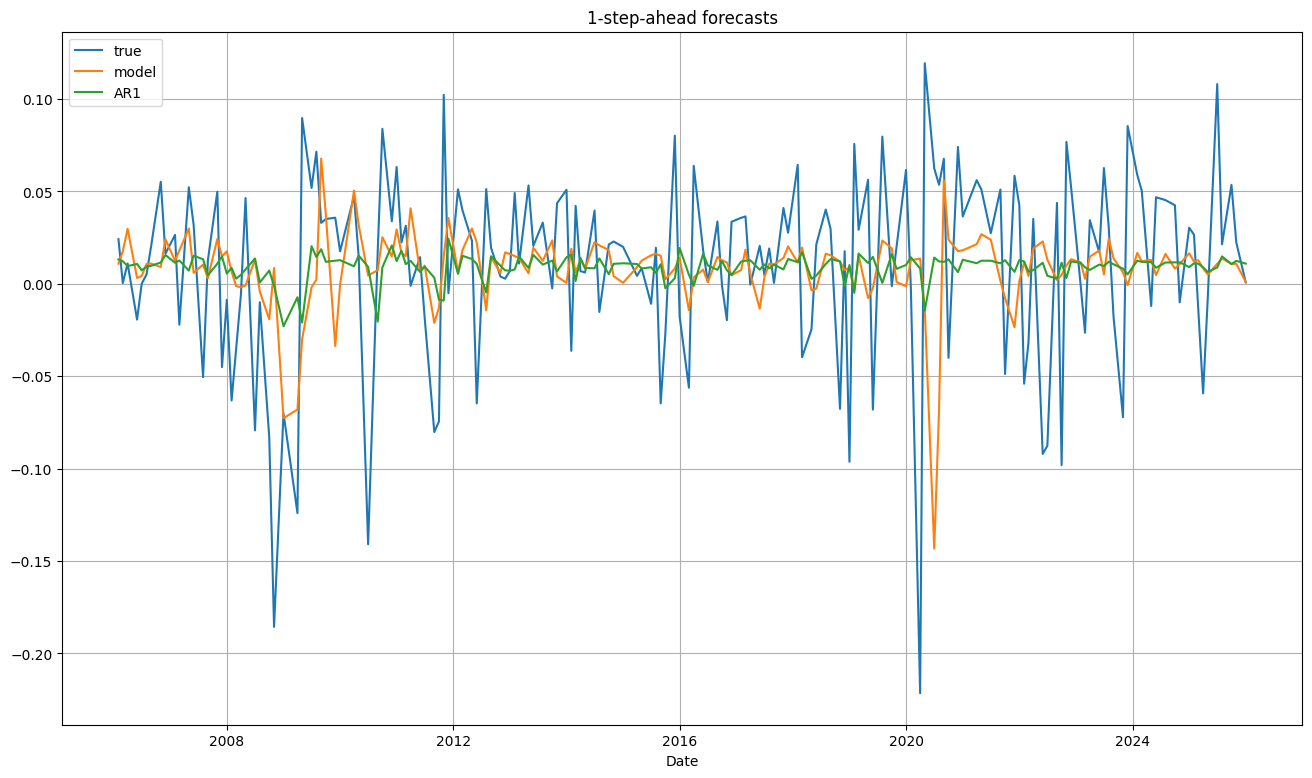

In [27]:
# collect 1-step-ahead forecasts in a DataFrame
df_pred = pd.DataFrame(
    {"true": test, "model": predictions, "AR1": predictions_ar}
)

# add dates and set index
df_pred["Time"] = dates[start_oos:]
df_pred = df_pred.set_index("Time")   # no trailing dot

# plot
fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(df_pred["true"], label="true")
ax.plot(df_pred["model"], label="model")
ax.plot(df_pred["AR1"], label="AR1")
ax.set_xlabel("Date")
ax.set_title("1-step-ahead forecasts")
ax.legend()
ax.grid(True)
plt.show()
